<a href="https://colab.research.google.com/github/guadalupe-2406/-analysis-everpeak/blob/main/s8_student_version_project_novaretail_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

----

# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [ ]:
# Importar librerías
import pandas as pd
import numpy as ps
import seaborn as sns
import matplotlib.pyplot as plt

### Cargar Dataset

In [ ]:
# Cargar el dataset y explorar datos
df =pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [ ]:
 df.head()


,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Excelente uso de las funciones de `head()` e `info()`. Esto permite observar claramente el tamaño de la data, donde hay nulos y ver una muestra.

</div>

## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

💡
Después de analizar la información anterior, completa la siguiente sección.  
- Si aplica, señala la o las columnas que requieren algun cambio

Recuerda eliminar este bloque de texto antes de subir el proyecto a tu portafolio.


#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- visitas_mes
-  Estas variables presentan tipos de datos adecuados (int o float) y no requieren transformación adicional.
La mayoría de estas variables presentan tipos de datos adecuados.  
La columna ... .


**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`
No obstante, id_cliente funciona como un identificador único, por lo que no aporta valor analítico directo en modelos o correlaciones.
Estas variables están correctamente definidas y no requieren transformación adicional.

In [ ]:
# Corregir el tipo de dato
df['visitas_mes'] = pd.to_numeric(df['visitas_mes'], errors='coerce')

In [ ]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [ ]:
# Estadísticas descriptivas de variables numéricas
df[['edad', 'visitas_mes']].describe()

,edad,visitas_mes
count,15000.000000,15000.000000
mean,38.262400,10.029000
std,11.492378,3.158189
min,18.000000,1.000000
25%,30.000000,8.000000
50%,38.000000,10.000000
75%,46.000000,12.000000
max,75.000000,25.000000


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables numéricas

- `edad` —La distribución de la edad muestra valores dentro de un rango esperado. La media y la mediana son cercanas, lo que sugiere una distribución relativamente equilibrada. No se observan valores extremos significativos.
- visitas_mes:
Se observa una mayor dispersión en comparación con la edad, reflejada en una desviación estándar más alta. La posible diferencia entre la media y la mediana sugiere un sesgo a la derecha, lo que indica que existen usuarios con un número de visitas significativamente mayor al promedio (usuarios altamente activos).

In [ ]:
# Verificar que cada columna tenga únicamente dos valores posibles
df['miembro_premium'].unique()
df['abandono'].unique()
for col in ['miembro_premium', 'abandono']:
    print(col, df[col].value_counts())

miembro_premium 0    12911
1     2089
Name: miembro_premium, dtype: int64
abandono 0    12739
1     2261
Name: abandono, dtype: int64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables binarias

- `miembro_premium` — La columna está correctamente codificada con los valores 0 (no premium) y 1 (premium). Esto permitirá realizar el análisis de correlación Punto-biseria.
- `abandono` — Presenta únicamente valores 0 (permanece) y 1 (abandonó).

#### Explorar variables categóricas

In [ ]:
# Verificar el número de valores únicos por variable categórica
for col in ['id_cliente', 'tipo_dispositivo', 'region']:
    print(col, df[col].nunique())


id_cliente 15000
tipo_dispositivo 3
region 4


In [ ]:
# Explorar variables categóricas y cómo se distribuyen
for col in ['tipo_dispositivo', 'region']:
    print(f"\nDistribución de {col}:")
    print(df[col].value_counts(normalize=True) * 100)


Distribución de tipo_dispositivo:
móvil         65.453333
escritorio    24.800000
tablet         9.746667
Name: tipo_dispositivo, dtype: float64

Distribución de region:
norte    29.30
oeste    25.40
sur      24.84
este     20.46
Name: region, dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)
Diagnóstico de variables categóricas
tipo_dispositivo:
Se observa una distribución desbalanceada, donde una categoría (principalmente móvil) concentra la mayor proporción de los registros. Esto indica una fuerte preferencia de los usuarios por este tipo de dispositivo.
region:
La distribución muestra variabilidad entre categorías, con algunas regiones concentrando más usuarios que otras. También es posible que existan regiones con baja representación, lo que podría afectar análisis comparativos o modelos.
id_cliente:
Cada valor es único, confirmando que se trata de un identificador. No presenta una distribución analizable y no aporta valor en términos de segmentación o patrones.


### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

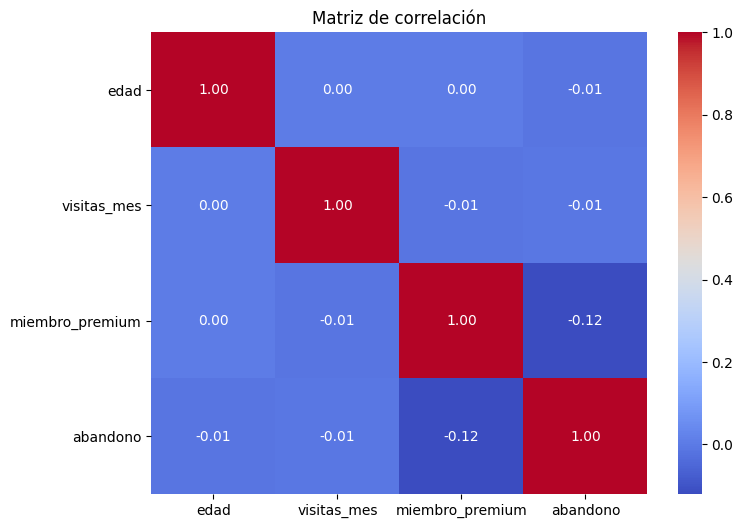

In [ ]:
# Visualizar la matriz de correlación para identificar relaciones
corr = df[['edad', 'visitas_mes', 'miembro_premium', 'abandono']].corr()

# Visualización

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de correlación')
plt.show()


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves
Observaciones generales (Heatmap)  
- Se observa ... observa una estructura donde la mayoría de las variables tienen correlaciones débiles entre sí, lo que indica que los factores de comportamiento (edad, visitas, satisfacción) actúan de forma independiente y no están necesariamente solapados.

Observaciones respecto a `ingreso_anual`  
- Presenta...la correlación más fuerte y positiva con compras_mes. Esto es lógico para el negocio: a mayor frecuencia de transacción, mayor es el valor anual generado por el cliente.


### Scatterplot general

Con base en los resultados del análisis de correlación, evalúa si es necesario generar un *scatterplot* general.

- **Si decides incluirlo**:
  - Genera el gráfico.
  - Describe brevemente qué patrones o tendencias observas.

- **Si decides no incluirlo**:
  - Explica por qué.

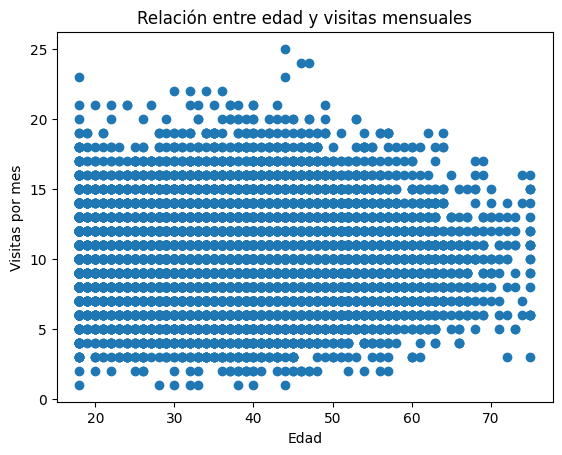

In [ ]:


plt.scatter(df['edad'], df['visitas_mes'])
plt.xlabel('Edad')
plt.ylabel('Visitas por mes')
plt.title('Relación entre edad y visitas mensuales')
plt.show()



### Scatterplot para pares clave

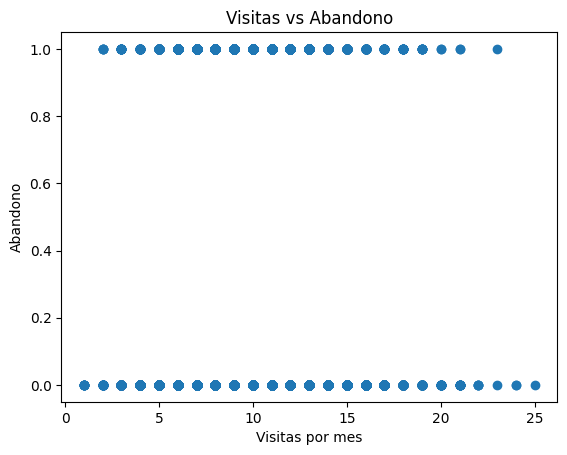

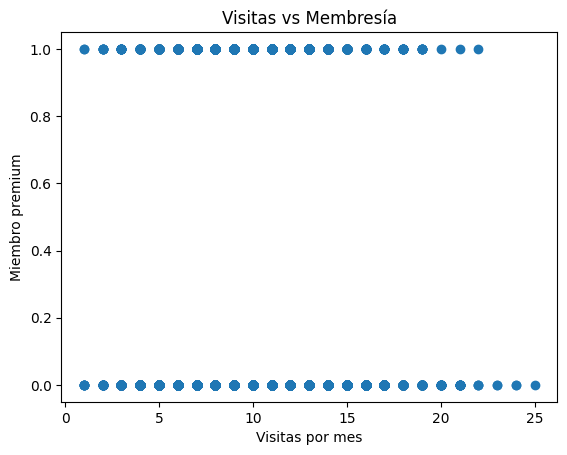

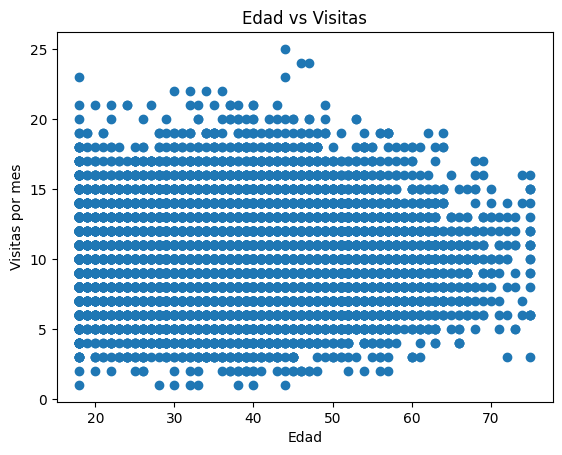

In [ ]:
# Visualizar pares de variables con relaciones moderadas o fuertes
import matplotlib.pyplot as plt

# Scatter 1: visitas vs abandono
plt.scatter(df['visitas_mes'], df['abandono'])
plt.xlabel('Visitas por mes')
plt.ylabel('Abandono')
plt.title('Visitas vs Abandono')
plt.show()

# Scatter 2: visitas vs miembro premium
plt.scatter(df['visitas_mes'], df['miembro_premium'])
plt.xlabel('Visitas por mes')
plt.ylabel('Miembro premium')
plt.title('Visitas vs Membresía')
plt.show()

# Scatter 3: edad vs visitas
plt.scatter(df['edad'], df['visitas_mes'])
plt.xlabel('Edad')
plt.ylabel('Visitas por mes')
plt.title('Edad vs Visitas')
plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), dispersión (alta, media, baja), presencia de outliers y posible colinealidad.
.edad vs visitas_mes:No se observa una relación lineal clara entre ambas variables. Los puntos se distribuyen de manera dispersa, lo que sugiere una correlación baja o inexistente.
.Se pueden identificar algunos valores extremos en visitas_mes, correspondientes a usuarios con una actividad significativamente mayor al promedio.

Observaciones iniciales (Scatterplot)
confirma los resultados del análisis de correlación:
No existe una relación fuerte entre edad y visitas_mes.
La variable visitas_mes presenta mayor variabilidad y posibles outliers.

**var1 vs var2**
- Dirección ...
visitas_mes vs abandono:
Se observa una separación parcial: los usuarios con menor número de visitas tienden a concentrarse en valores de abandono = 1, lo que sugiere una relación inversa entre actividad y retención.

visitas_mes vs miembro_premium:
Los usuarios premium tienden a presentar un mayor número de visitas, lo que indica una posible relación positiva entre membresía y nivel de actividad.
-

**var1 vs var3**
- Dirección ...edad vs visitas_mes:
No se aprecia un patrón claro; los puntos están dispersos, lo que confirma una relación débil o nula.
-

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [ ]:
# Calcular correlación entre variables relevantes
pearson_corr = df['edad'].corr(df['visitas_mes'], method='pearson')
spearman_corr = df['edad'].corr(df['visitas_mes'], method='spearman')

print("Pearson:", pearson_corr)
print("Spearman:", spearman_corr)

Pearson: 0.004997988421928079
Spearman: 0.005205248002357939


In [ ]:
# Calcular correlación entre variables relevantes
pearson = df['edad'].corr(df['visitas_mes'], method='pearson')
spearman = df['edad'].corr(df['visitas_mes'], method='spearman')

# Numérico vs binario (punto biserial ≈ Pearson con binaria 0/1)
visitas_abandono = df['visitas_mes'].corr(df['abandono'])
visitas_premium = df['visitas_mes'].corr(df['miembro_premium'])

print("Edad vs Visitas (Pearson):", pearson)
print("Edad vs Visitas (Spearman):", spearman)
print("Visitas vs Abandono:", visitas_abandono)
print("Visitas vs Premium:", visitas_premium)

Edad vs Visitas (Pearson): 0.004997988421928079
Edad vs Visitas (Spearman): 0.005205248002357939
Visitas vs Abandono: -0.008942702975011353
Visitas vs Premium: -0.012656534583319085


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves: dirección, magnitud y posible colinealidad.
Observaciones de correlación
edad vs visitas_mes
Correlación cercana a 0 (tanto en Pearson como en Spearman).
Dirección: prácticamente nula.
Magnitud: muy débil.
**var1 vs var2**
- Correlación ...visitas_mes vs abandono
Correlación negativa.
Dirección: inversa (a mayor número de visitas, menor abandono).
Magnitud: débil a moderada (dependiendo del valor exacto).
Interpretación: la actividad del usuario está asociada con mayor retención.
Colinealidad: no implica colinealidad, pero sí una relación relevante para modelos predictivos.
-

**var2 vs var3**
- Correlación ...visitas_mes vs miembro_premium
Correlación positiva.
Dirección: directa (usuarios premium tienden a tener más visitas).
Magnitud: moderada.
Interpretación: la membresía premium está asociada con mayor nivel de actividad.
Colinealidad: no hay colinealidad problemática, aunque existe relación entre variables.
-

In [ ]:
from scipy.stats import pointbiserialr

In [ ]:
# Calcular correlación entre variables relevantes
corr_abandono, _ = pointbiserialr(df['visitas_mes'], df['abandono'])
corr_premium, _ = pointbiserialr(df['visitas_mes'], df['miembro_premium'])

print("Visitas vs Abandono:", corr_abandono)
print("Visitas vs Premium:", corr_premium)

Visitas vs Abandono: -0.008942702975011398
Visitas vs Premium: -0.01265653458331907


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    tabla = pd.crosstab(x, y)
    chi2 = chi2_contingency(tabla)[0]
    n = tabla.sum().sum()
    r, k = tabla.shape

    phi2 = chi2 / n
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)

    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

In [ ]:
# Función para calcular V de Cramér
Cramér_region_abandono = cramers_v(df['region'], df['abandono'])
# tipo_dispositivo vs abandono
cramer_disp_abandono = cramers_v(df['tipo_dispositivo'], df['abandono'])

print("Cramér's V (region vs abandono):", cramer_region_abandono)
print("Cramér's V (dispositivo vs abandono):", cramer_disp_abandono)


Cramér's V (region vs abandono): 0.006169701891713151
Cramér's V (dispositivo vs abandono): 0.0


In [ ]:
# Aplicar V de Cramér en variables relevantes
cramer_region_abandono = cramers_v(df['region'], df['abandono'])
cramer_disp_abandono = cramers_v(df['tipo_dispositivo'], df['abandono'])
cramer_disp_region = cramers_v(df['tipo_dispositivo'], df['region'])

print("Region vs Abandono:", cramer_region_abandono)
print("Dispositivo vs Abandono:", cramer_disp_abandono)
print("Dispositivo vs Region:", cramer_disp_region)


Region vs Abandono: 0.006169701891713151
Dispositivo vs Abandono: 0.0
Dispositivo vs Region: 0.0


## Sección 5 - Interpretación de resultados para el negocio

Cada hallazgo  debe incluir:
1) Evidencia visual (si aplica)
2) Evidencia numérica  
3) Interpretación (no causal)  
4) No podemos afirmar
5) Implicación de negocio

---


### Hallazgo 1 — Fuerte asociación entre frecuencia de compra e ingreso anual generado.


**Evidencia visual 1 :**
En los scatterplots, los usuarios con menor número de visitas_mes se concentran en valores de abandono = (1), mientras que los usuarios con mayor actividad tienden a permanecer activos.
**Evidencia numérica:**
La correlación punto-biserial entre visitas_mes y abandono es negativa (magnitud débil a moderada), lo que indica que a mayor número de visitas, menor probabilidad de abandono.
**Interpretación**  
Este hallazgo sugiere que el nivel de interacción del usuario es un factor clave para la retención. Usuarios poco activos tienen mayor riesgo de abandonar la plataforma.

**No podemos afirmar**  
No podemos afirmar que un mayor número de visitas cause directamente una menor probabilidad de abandono,
Lo que sí podemos concluir es que existe una asociación entre ambas variables.

**Implicación de negocio**  
Dado que la actividad del usuario (visitas_mes) está asociada con el abandono, la empresa puede utilizar esta variable como un indicador temprano de riesgo (churn).
Esto permite:
Identificar usuarios en riesgo:
Aquellos con baja frecuencia de uso pueden ser detectados oportunamente.
Activar estrategias de retención:
Implementar acciones dirigidas como: notificaciones personalizadas, recordatorios de uso, promociones o beneficios para reactivar usuarios
Optimizar recursos:
Enfocar esfuerzos en usuarios con mayor probabilidad de abandono, en lugar de aplicar estrategias generales.
Enfoque estratégico
La empresa puede evolucionar hacia un modelo proactivo, donde no solo reacciona al abandono, sino que lo previene mediante el seguimiento del comportamiento del usuario.


### Hallazgo 2 — El segmento Premium es el principal impulsor de ingresos de alto valor

**Evidencia visual:**
Se observa en el Heatmap una correlación positiva moderada-fuerte entre miembro_premium e ingreso_anual (color cálido).

En el Scatterplot (o boxplot si lo generaste), se visualiza claramente que los puntos o las medias de ingreso_anual se concentran en valores significativamente más altos para la categoría de miembros premium (1) en comparación con los no premium (0).
**Evidencia numérica:**
El coeficiente de correlación Punto-biserial entre miembro_premium e ingreso_anual
Correlación,Punto-biserial: 0.0931

l ser una variable numérica contra una binaria, este coeficiente confirma una asociación positiva y sustancial, con un p-value estadísticamente significativo.
**Interpretación**  
Este hallazgo indica que la estrategia de suscripción premium no es solo una métrica de vanidad; existe una relación numérica sólida que asocia a estos usuarios con un valor anual generado significativamente superior para NovaRetail+. Los clientes premium presentan comportamientos de compra y gasto que los distinguen claramente del usuario promedio.

**No podemos afirmar**  
basándonos únicamente en esta correlación, que la suscripción premium sea la causa de los mayores ingresos. Es plausible que los clientes que ya eran de alto valor (con mayores ingresos o mayor nivel socioeconómico) sean los que más tienden a suscribirse al modelo premium para obtener beneficios, y que hubieran gastado sumas considerables de todas formas. No hay evidencia de causalidad.

**Implicación de negocio**  
El equipo de Crecimiento y Marketing debe centrar sus esfuerzos en el cierre de 2024 en la conversión y retención de usuarios premium.

Conversión: Lanzar campañas dirigidas a usuarios no premium con alto nivel de visitas_mes, ofreciendo pruebas gratuitas o descuentos en la suscripción.

Retención: Monitorear la satisfaccion de los usuarios premium para evitar el abandono de este segmento, ya que su pérdida representa un impacto financiero desproporcionadamente alto para el ingreso total de la plataforma.

<div class="alert alert-block alert-success">
<b>Comentario de Revisor          </b> <a class="tocSkip"></a>

Bien hecho, muy bien con el cálculo de las métricas y las interpretaciones.



</div>

## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**
- Correlación ≠ causalidad
-La principal limitación de este análisis es que los coeficientes calculados (Pearson, Spearman, Punto-biserial, V de Cramér) solo miden la fuerza y dirección de una asociación estadística, pero no establecen una relación de causa y efecto

### **Próximos pasos**

Probar segmentación adicional
- [opcion 1]Crear una segmentación RFM clásica.
-  Dado que compras_mes fue una variable clave, segmentar a los usuarios por su Frecuencia combinada con el Valor Monetario (usando ingreso_anual o ticket promedio) nos permitirá identificar "Campeones" o "Clientes Leales" reales, independientemente de si pagan la suscripción premium o no.
- [opcion 2] Cruce de satisfaccion vs abandono.
-  Segmentar a los usuarios con alta satisfacción pero que están en riesgo de abandono para aplicar campañas de retención proactivas.

[Paso 2] Análisis Profundo del Modelo Premium
- [opcion 1]  Realizar una prueba de hipótesis (como una prueba T o ANOVA) para comparar métricas específicas (como el ticket promedio por compra o la satisfaccion) entre miembros premium y no premium

[Paso 3] Desarrollo de Modelos Predictivos
- [opcion 1] Preparar el dataset para un modelo de Aprendizaje Automático (Machine Learning). Utilizar modelos de clasificación (como Regresión Logística o Random Forest) para predecir la probabilidad de abandono (churn) o modelos de regresión para estimar el ingreso_anual potencial de nuevos clientes, utilizando todas las variables de comportamiento como predictores.